<a href="https://colab.research.google.com/github/EnasIbrahimAli2005/MNIST-Digit-Classification-Project/blob/main/MNIST(Enas_Ibrahiem).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade keras

In [ ]:
import keras
print(keras.__version__)


3.5.0


In [ ]:
keras.datasets.mnist.load_data(path="mnist.npz")

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 0.3180 - val_loss: 0.1778
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.1701 - val_loss: 0.1507
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.1489 - val_loss: 0.1409
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1402 - val_loss: 0.1341
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.1342 - val_loss: 0.1302
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1304 - val_loss: 0.1273
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1274 - val_loss: 0.1250
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1247 - val_loss: 0.1231
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1230 - val_loss: 0.1214
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1212 - val_loss: 0.1205
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


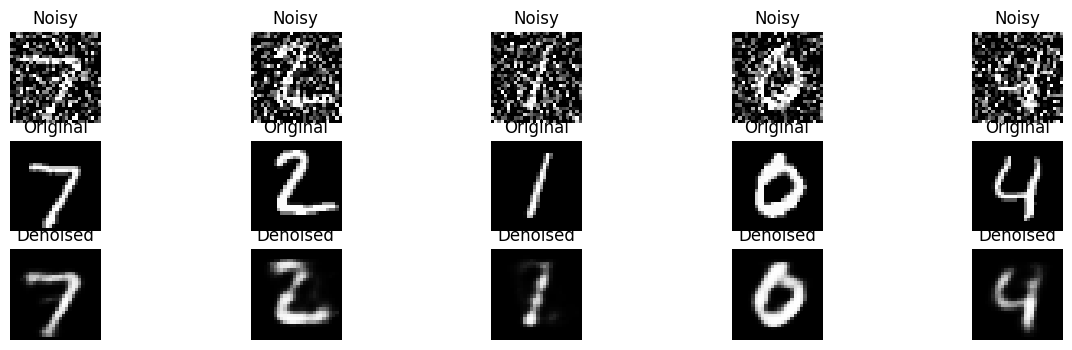

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# Load MNIST dataset
#(x_train, y_train), (x_test, y_test) = mnist.load_data()
#x_train = x_train.astype('float32') / 255.0  # Normalize the data
#x_test = x_test.astype('float32') / 255.0

# Function to add Gaussian noise to images
def add_gaussian_noise(images, noise_factor=0.5):
    noisy_images = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy_images = np.clip(noisy_images, 0., 1.)  # Keep pixel values between 0 and 1
    return noisy_images

# Add Gaussian noise to training and testing data
x_train_noisy = add_gaussian_noise(x_train, noise_factor=0.5)
x_test_noisy = add_gaussian_noise(x_test, noise_factor=0.5)

# Reshape data to be in vector form
x_train_noisy_flat = x_train_noisy.reshape(-1, 28 * 28)
x_test_noisy_flat = x_test_noisy.reshape(-1, 28 * 28)
x_train_flat = x_train.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)

# Build the model using Dense layers
input_img = Input(shape=(28 * 28,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)

decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(28 * 28, activation='sigmoid')(decoded)

# Create the model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the model
autoencoder.fit(
    x_train_noisy_flat, x_train_flat,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy_flat, x_test_flat)
)

# Use the model to denoise the images
denoised_images_flat = autoencoder.predict(x_test_noisy_flat)
denoised_images = denoised_images_flat.reshape(-1, 28, 28)

# Display original, noisy, and denoised images
n = 5  # Number of images to display
plt.figure(figsize=(15, 4))
for i in range(n):
    # Display noisy images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i], cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Display original images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Display denoised images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_images[i], cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.show()
